# 11 — Unsupervised Weather Regime Analysis

This notebook applies unsupervised learning to identify recurring meteorological regimes in Recife.

K-Means clustering is performed exclusively using current meteorological observations:

- precipitation;
- temperature;
- relative humidity;
- atmospheric pressure.

No severe-rainfall target is used during cluster formation.

Because hourly precipitation has a strongly skewed distribution, a logarithmic transformation is applied before clustering.

The number of clusters is selected using the Silhouette Score for candidate values from 2 to 6.

After the clusters are created, rainfall occurrence and severe-rainfall frequency are analyzed only for interpretation.

=== DATASET LOADED ===

Start: 2018-01-01 00:00:00+00:00
End: 2021-11-12 06:00:00+00:00
Rows: 33871

=== CLUSTERING DATA AVAILABILITY ===
Rows available: 33193
Rows removed due to missing values: 678
Availability: 98.00%

Meteorological variables standardized.

=== CLUSTER NUMBER SELECTION ===


,n_clusters,silhouette_score,inertia
0,2,0.3515,83972.4875
1,3,0.3764,60480.2851
2,4,0.3114,48259.8605
3,5,0.3180,38527.8115
4,6,0.3119,33000.1554



Selected number of clusters: 3
Best silhouette score: 0.3764

Clusters reordered from lowest to highest mean precipitation.

=== CLUSTER PROFILE ===


,cluster,samples,share_pct,precipitation_mean_mm,precipitation_median_mm,precipitation_max_mm,temperature_mean_c,humidity_mean_pct,pressure_mean_mb,rainy_pct,severe_hours,severe_pct
0,0,15376,46.323,0.006,0.0,1.8,28.378,66.435,1012.099,1.971,0,0.00
1,1,16207,48.827,0.066,0.0,1.0,23.892,86.954,1013.434,15.839,0,0.00
2,2,1610,4.850,3.888,2.4,45.6,23.769,91.561,1013.507,100.000,109,6.77



=== SEVERE RAIN IN NEXT 1H BY CLUSTER ===


,cluster,valid_target_1h,severe_next_1h,severe_next_1h_pct
0,0,15367,7.0,0.046
1,1,16169,43.0,0.266
2,2,1608,59.0,3.669



=== CLUSTER DISTRIBUTION BY YEAR (%) ===


cluster,0,1,2
year,,,
2018,46.70,49.43,3.88
2019,44.98,49.86,5.16
2020,50.62,45.32,4.07
2021,42.39,51.10,6.50



=== PCA EXPLAINED VARIANCE ===
PC1: 0.531
PC2: 0.233
Total: 0.764


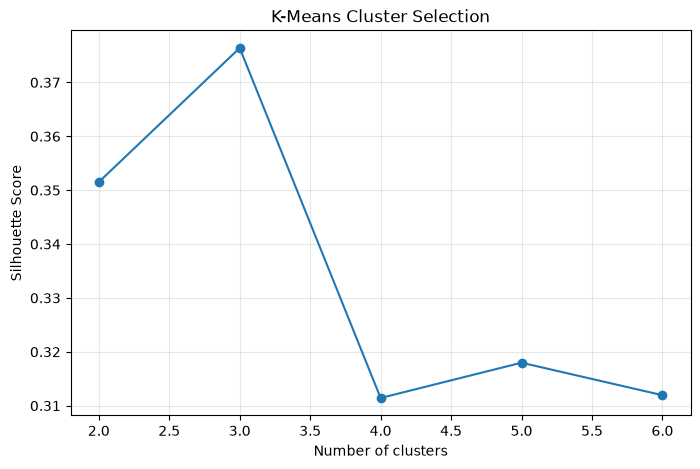

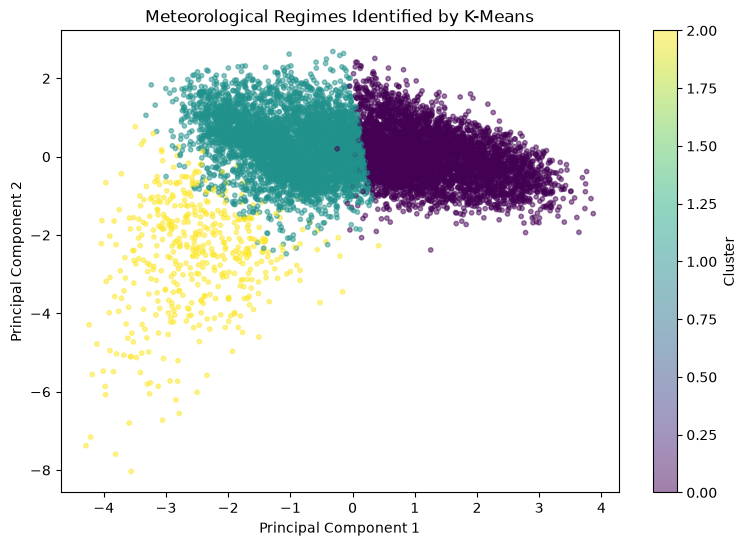


Cluster dataset saved to:
..\data\processed\recife_2018_2021_clusters.csv


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. CONFIGURATION
# ============================================================

INPUT_PATH = Path(
    "../data/processed/recife_2018_2021_model_dataset.csv"
)

OUTPUT_PATH = Path(
    "../data/processed/recife_2018_2021_clusters.csv"
)

RANDOM_STATE = 42

SEVERE_THRESHOLD_MM = 10.0

CANDIDATE_CLUSTERS = [
    2,
    3,
    4,
    5,
    6,
]


# ============================================================
# 2. LOAD DATA
# ============================================================

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {INPUT_PATH}"
    )


df = pd.read_csv(
    INPUT_PATH,
    parse_dates=["datetime_utc"],
)

df = (
    df
    .set_index("datetime_utc")
    .sort_index()
)


print("=== DATASET LOADED ===")
print()

print(
    "Start:",
    df.index.min()
)

print(
    "End:",
    df.index.max()
)

print(
    "Rows:",
    len(df)
)


# ============================================================
# 3. CLUSTERING VARIABLES
# ============================================================

BASE_CLUSTER_FEATURES = [
    "precipitation_mm",
    "temperature_c",
    "humidity_pct",
    "pressure_station_mb",
]


cluster_data = df[
    BASE_CLUSTER_FEATURES
].copy()


cluster_data = cluster_data.dropna()


print()
print(
    "=== CLUSTERING DATA AVAILABILITY ==="
)

print(
    "Rows available:",
    len(cluster_data)
)

print(
    "Rows removed due to missing values:",
    len(df) - len(cluster_data)
)

print(
    "Availability:",
    f"{len(cluster_data) / len(df) * 100:.2f}%"
)


# ============================================================
# 4. PRECIPITATION TRANSFORMATION
# ============================================================

cluster_data[
    "precipitation_log1p"
] = np.log1p(
    cluster_data[
        "precipitation_mm"
    ]
)


CLUSTER_FEATURES = [
    "precipitation_log1p",
    "temperature_c",
    "humidity_pct",
    "pressure_station_mb",
]


# ============================================================
# 5. STANDARDIZATION
# ============================================================

scaler = StandardScaler()


X_scaled = scaler.fit_transform(
    cluster_data[
        CLUSTER_FEATURES
    ]
)


print()
print(
    "Meteorological variables standardized."
)


# ============================================================
# 6. SELECT NUMBER OF CLUSTERS
# ============================================================

cluster_selection_results = []


silhouette_sample_size = min(
    5000,
    len(cluster_data),
)


for k in CANDIDATE_CLUSTERS:

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20,
    )


    labels = model.fit_predict(
        X_scaled
    )


    silhouette = silhouette_score(
        X_scaled,
        labels,
        sample_size=silhouette_sample_size,
        random_state=RANDOM_STATE,
    )


    cluster_selection_results.append(
        {
            "n_clusters":
                k,

            "silhouette_score":
                silhouette,

            "inertia":
                model.inertia_,
        }
    )


cluster_selection_df = pd.DataFrame(
    cluster_selection_results
)


print()
print(
    "=== CLUSTER NUMBER SELECTION ==="
)

display(
    cluster_selection_df.round(4)
)


# ============================================================
# 7. SELECT BEST K
# ============================================================

best_row = (
    cluster_selection_df
    .sort_values(
        "silhouette_score",
        ascending=False,
    )
    .iloc[0]
)


BEST_K = int(
    best_row[
        "n_clusters"
    ]
)


print()
print(
    "Selected number of clusters:",
    BEST_K
)

print(
    "Best silhouette score:",
    round(
        best_row[
            "silhouette_score"
        ],
        4,
    )
)


# ============================================================
# 8. FIT FINAL K-MEANS
# ============================================================

final_kmeans = KMeans(
    n_clusters=BEST_K,
    random_state=RANDOM_STATE,
    n_init=20,
)


cluster_data[
    "cluster_raw"
] = final_kmeans.fit_predict(
    X_scaled
)


# ============================================================
# 9. ORDER CLUSTERS BY MEAN PRECIPITATION
# ============================================================

cluster_precip_order = (
    cluster_data
    .groupby(
        "cluster_raw"
    )[
        "precipitation_mm"
    ]
    .mean()
    .sort_values()
)


cluster_mapping = {
    original_cluster:
        ordered_cluster

    for ordered_cluster,
        original_cluster
    in enumerate(
        cluster_precip_order.index
    )
}


cluster_data[
    "cluster"
] = (
    cluster_data[
        "cluster_raw"
    ]
    .map(
        cluster_mapping
    )
)


cluster_data[
    "cluster"
] = (
    cluster_data[
        "cluster"
    ]
    .astype(int)
)


print()
print(
    "Clusters reordered from lowest to highest mean precipitation."
)


# ============================================================
# 10. ADD INTERPRETATION VARIABLES
# ============================================================

cluster_data[
    "rainy_hour"
] = (
    cluster_data[
        "precipitation_mm"
    ]
    > 0
)


cluster_data[
    "severe_current"
] = (
    cluster_data[
        "precipitation_mm"
    ]
    >= SEVERE_THRESHOLD_MM
)


if "target_1h" in df.columns:

    cluster_data[
        "target_1h"
    ] = df.loc[
        cluster_data.index,
        "target_1h",
    ]


# ============================================================
# 11. CLUSTER PROFILE
# ============================================================

cluster_profile = (
    cluster_data
    .groupby(
        "cluster"
    )
    .agg(
        samples=(
            "precipitation_mm",
            "size",
        ),

        precipitation_mean_mm=(
            "precipitation_mm",
            "mean",
        ),

        precipitation_median_mm=(
            "precipitation_mm",
            "median",
        ),

        precipitation_max_mm=(
            "precipitation_mm",
            "max",
        ),

        temperature_mean_c=(
            "temperature_c",
            "mean",
        ),

        humidity_mean_pct=(
            "humidity_pct",
            "mean",
        ),

        pressure_mean_mb=(
            "pressure_station_mb",
            "mean",
        ),

        rainy_hours=(
            "rainy_hour",
            "sum",
        ),

        severe_hours=(
            "severe_current",
            "sum",
        ),
    )
    .reset_index()
)


cluster_profile[
    "share_pct"
] = (
    cluster_profile[
        "samples"
    ]
    / len(cluster_data)
    * 100
)


cluster_profile[
    "rainy_pct"
] = (
    cluster_profile[
        "rainy_hours"
    ]
    / cluster_profile[
        "samples"
    ]
    * 100
)


cluster_profile[
    "severe_pct"
] = (
    cluster_profile[
        "severe_hours"
    ]
    / cluster_profile[
        "samples"
    ]
    * 100
)


print()
print(
    "=== CLUSTER PROFILE ==="
)

display(
    cluster_profile[
        [
            "cluster",
            "samples",
            "share_pct",
            "precipitation_mean_mm",
            "precipitation_median_mm",
            "precipitation_max_mm",
            "temperature_mean_c",
            "humidity_mean_pct",
            "pressure_mean_mb",
            "rainy_pct",
            "severe_hours",
            "severe_pct",
        ]
    ].round(3)
)


# ============================================================
# 12. +1H SEVERE RAIN ASSOCIATION
# ============================================================

if "target_1h" in cluster_data.columns:

    future_analysis = (
        cluster_data[
            cluster_data[
                "target_1h"
            ]
            .notna()
        ]
        .groupby(
            "cluster"
        )
        ["target_1h"]
        .agg(
            [
                "count",
                "sum",
                "mean",
            ]
        )
        .reset_index()
    )


    future_analysis.columns = [
        "cluster",
        "valid_target_1h",
        "severe_next_1h",
        "severe_next_1h_rate",
    ]


    future_analysis[
        "severe_next_1h_pct"
    ] = (
        future_analysis[
            "severe_next_1h_rate"
        ]
        * 100
    )


    print()
    print(
        "=== SEVERE RAIN IN NEXT 1H BY CLUSTER ==="
    )

    display(
        future_analysis[
            [
                "cluster",
                "valid_target_1h",
                "severe_next_1h",
                "severe_next_1h_pct",
            ]
        ].round(3)
    )


# ============================================================
# 13. CLUSTER DISTRIBUTION BY YEAR
# ============================================================

cluster_data[
    "year"
] = (
    cluster_data.index.year
)


year_distribution = (
    pd.crosstab(
        cluster_data[
            "year"
        ],
        cluster_data[
            "cluster"
        ],
        normalize="index",
    )
    * 100
)


print()
print(
    "=== CLUSTER DISTRIBUTION BY YEAR (%) ==="
)

display(
    year_distribution.round(2)
)


# ============================================================
# 14. PCA FOR 2D VISUALIZATION
# ============================================================

pca = PCA(
    n_components=2
)


X_pca = pca.fit_transform(
    X_scaled
)


cluster_data[
    "pca_1"
] = X_pca[:, 0]

cluster_data[
    "pca_2"
] = X_pca[:, 1]


print()
print(
    "=== PCA EXPLAINED VARIANCE ==="
)

print(
    "PC1:",
    round(
        pca.explained_variance_ratio_[0],
        3,
    )
)

print(
    "PC2:",
    round(
        pca.explained_variance_ratio_[1],
        3,
    )
)

print(
    "Total:",
    round(
        pca.explained_variance_ratio_.sum(),
        3,
    )
)


# ============================================================
# 15. PLOT — SILHOUETTE SCORE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    cluster_selection_df[
        "n_clusters"
    ],
    cluster_selection_df[
        "silhouette_score"
    ],
    marker="o",
)

plt.xlabel(
    "Number of clusters"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "K-Means Cluster Selection"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 16. PLOT — PCA CLUSTER MAP
# ============================================================

plot_sample = (
    cluster_data
    .sample(
        n=min(
            10000,
            len(cluster_data),
        ),
        random_state=RANDOM_STATE,
    )
)


plt.figure(
    figsize=(9, 6)
)

scatter = plt.scatter(
    plot_sample[
        "pca_1"
    ],
    plot_sample[
        "pca_2"
    ],
    c=plot_sample[
        "cluster"
    ],
    s=10,
    alpha=0.5,
)

plt.xlabel(
    "Principal Component 1"
)

plt.ylabel(
    "Principal Component 2"
)

plt.title(
    "Meteorological Regimes Identified by K-Means"
)

plt.colorbar(
    scatter,
    label="Cluster",
)

plt.show()


# ============================================================
# 17. SAVE CLUSTER ASSIGNMENTS
# ============================================================

columns_to_save = [
    "precipitation_mm",
    "temperature_c",
    "humidity_pct",
    "pressure_station_mb",
    "cluster",
    "rainy_hour",
    "severe_current",
]


if "target_1h" in cluster_data.columns:

    columns_to_save.append(
        "target_1h"
    )


cluster_data[
    columns_to_save
].to_csv(
    OUTPUT_PATH,
    index=True,
)


print()
print(
    "Cluster dataset saved to:"
)

print(
    OUTPUT_PATH
)

In [2]:
# ============================================================
# 18. HUMAN-READABLE CLUSTER LABELS
# ============================================================

CLUSTER_LABELS = {
    0: "warm_dry",
    1: "humid_low_rain",
    2: "rainy_high_humidity",
}


cluster_data[
    "cluster_label"
] = (
    cluster_data[
        "cluster"
    ]
    .map(CLUSTER_LABELS)
)


print(
    "=== CLUSTER LABELS ==="
)

display(
    cluster_data[
        [
            "cluster",
            "cluster_label",
        ]
    ]
    .drop_duplicates()
    .sort_values("cluster")
)


columns_to_save = [
    "precipitation_mm",
    "temperature_c",
    "humidity_pct",
    "pressure_station_mb",
    "cluster",
    "cluster_label",
    "rainy_hour",
    "severe_current",
]


if "target_1h" in cluster_data.columns:
    columns_to_save.append(
        "target_1h"
    )


cluster_data[
    columns_to_save
].to_csv(
    OUTPUT_PATH,
    index=True,
)


print(
    "Updated cluster dataset saved to:",
    OUTPUT_PATH
)

=== CLUSTER LABELS ===


,cluster,cluster_label
datetime_utc,,
2018-01-03 13:00:00+00:00,0,warm_dry
2018-01-04 06:00:00+00:00,1,humid_low_rain
2018-01-11 13:00:00+00:00,2,rainy_high_humidity


Updated cluster dataset saved to: ..\data\processed\recife_2018_2021_clusters.csv


## Conclusion

K-Means clustering identified three recurring meteorological regimes in the Recife dataset.

The best configuration contained three clusters and achieved a Silhouette Score of 0.3764.

The regimes can be interpreted as:

- Cluster 0 — warm and dry conditions;
- Cluster 1 — humid conditions with little precipitation;
- Cluster 2 — rainy and high-humidity conditions.

Cluster 2 represented only 4.85% of the analyzed observations, but contained all 109 severe-rainfall hours identified in the dataset.

Furthermore, severe rainfall during the following hour occurred in approximately 3.67% of Cluster 2 observations, compared with 0.27% in Cluster 1 and 0.05% in Cluster 0.

These results show that unsupervised learning can identify a meteorological regime strongly associated with severe rainfall conditions, although the clusters themselves should not be interpreted as causal or independent forecasting models.

The first two PCA components explained approximately 76.4% of the variance, providing a useful two-dimensional visualization of the identified meteorological regimes.

This completes the unsupervised-learning stage of the project.